## **Dự đoán khả năng bỏ học và hoàn thành chương trình của sinh viên**

Trong bối cảnh giáo dục hiện đại, việc theo dõi và hỗ trợ sinh viên một cách hiệu quả là yếu tố quan trọng để đảm bảo rằng họ có thể hoàn thành được chương trình học tập của mình một cách thành công nhất. Tuy nhiên, không phải tất cả sinh viên đều có thể hoàn thành quá trình học tập này một cách suôn sẻ được, có rất nhiều yếu tố sẽ ảnh hưởng đến quá trình học tập của họ, và việc hỗ trợ kịp thời là một điều cần thiết, nhưng việc tìm ra những sinh viên có khả năng bỏ học trong một bộ dữ liệu của một trường đại học là một điều khó khăn. Cho nên trong dự án lần này, chúng tôi đã ứng dụng công nghệ Machine Learning để dự đoán khả năng bỏ học hoặc hoàn thành khóa học của từng sinh viên dựa trên những yếu tố có thể ảnh hưởng đến quá trình học tập của họ.


<div align="center">
    <img 
        src="https://www.tabsgi.com/wp-content/uploads/2024/07/Untitled-1-1024x576.jpg"
        width="500px"
    >
</div>

Dự án **Dự đoán khả năng bỏ học và hoàn thành chương trình của sinh viên bằng Machine Learnin** là một một ứng dụng ứng dụng cộng nghệ tiên tiến của Machine Learning vào việc quản lý và hỗ trợ sinh viên tại các trường đại học. Mục tiêu của dự án là phát triển một hệ thống sử dụng các thuật toán của Machine Learning dùng để phân tích dữ liệu của sinh viên, và từ đó có thể dự đoán được khả năng bỏ học và khả năng hoàn thành khóa học của từng sinh viên. Dữ liệu đầu vào có thể sẽ bao gồm thông tin về kết quả học tập, hoàn cảnh gia đình, ngành học, các yếu tố xã hội và tài chính của sinh viên.

## **1. Thư viện**

Để thực hiện được dự án này, chúng ta sẽ cần phải sử dụng một vài thư viện ngoài của **Python**, cụ thể sẽ là thư viện **Pandas** đây là một mã nguồn mạnh mẽ cung cấp cho chúng ta các hàm làm việc với dữ liệu dạng `DataFrame` hoặc có thể biết đến là dữ liệu dạng bảng một cách hiệu quả như xóa cột, xóa dòng, tìm dòng theo câu loại điều kiện, xử lý theo từng cột riêng lẻ,... Bên cạnh thư viện Pandas thì chúng ta có thư viện **Numpy** đây là một thư viện chuyên xử lý các bài toán dạng mảng hoặc ma trận một cách hiệu quả thay vì xử lý các list thủ công như trong Python, việc kết hợp hai thư viện **Numpy** và **Pandas** sẽ giúp chúng ta làm việc hiệu quả hơn trong quá trình tiền xử lý dữ liệu ban đầu. Ngoài ra, chúng ta còn có các thư viện hỗ trợ trong quá trình trực quan hóa có thể kể đến như **Matplotlib** và **Seaborn**, đây là 2 thư viện mạnh mẽ giúp chúng ta trực quan hóa dữ liệu một cách sinh động bằng biểu đồ để có cái nhìn khách quan hơn về dữ liệu mà chúng ta đang làm. Và cuối cùng, khi nhắc đến làm việc với các bài toán về Machine Learning thì không thể không nói đến thư viện **Scikit-Learn** đây là một thư viện vô cùng mạnh mẽ mà hầu như ai đã học qua Machine Learning đều nên biết, thư viên cung cấp các Class, các hàm hỗ trỡ chúng ta trong quá trình tách dữ liệu, chuẩn hóa dữ liệu, xây dựng và huấn luyện mô hình, và cuối cùng là đánh giá mô hình.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

## **2. Dữ liệu**

Để thực hiện được dự án này, chúng tôi đã sử dụng bộ dữ liệu là **[Predict Student's Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)** từ **UCI**. Đây là một bộ dữ liệu được thu thập từ một cơ sở giáo dục đại học, nhằm mục đích dự đoán khả năng bỏ học và thành công học tập của sinh viên dựa trên các thông tin có sẵn tại thời điểm nhập học và kết quả học tập sau hai kỳ đầu tiên. Bộ dữ liệu này bao gồm nhiều đặc trưng (features) liên quan đến thông tin nhập học, gia đình và các yếu tố kinh tế xã hội. Bộ dữ liệu này có tổng cộng 36 đặc trưng (features) và một biến mục tiêu (target variable) là trạng thái học tập của sinh viên (Dropout, Enrolled, Graduated). Bảng bên dưới là thông tin tóm tắt của từng đặc trưng

| Feature Name | Ý Nghĩa | Giá Trị |
| -- | -- | -- |
| Marital Status                                 | Trạng thái hôn nhân của sinh viên tại thời điểm nhập học.               | 1: Độc thân, 2: Đã kết hôn, 3: Góa, 4: Ly hôn, 5: Sống chung không kết hôn, 6: Ly thân hợp pháp |
| Application Mode                               | Cách thức sinh viên đăng ký vào trường.                                  | 1: Giai đoạn ứng tuyển đầu tiên, 17: Ứng tuyển qua kỳ thi quốc gia, 39: Ứng viên trên 23 tuổi |
| Application Order                              | Thứ tự ưu tiên của trường/khóa học mà sinh viên chọn.                   | 0: Không ưu tiên, 1-9: Mức độ ưu tiên từ cao đến thấp                                        |
| Course                                         | Mã khóa học mà sinh viên đăng ký.                                        | 33: Công nghệ sinh học, 171: Thiết kế hoạt hình, 9119: Điều dưỡng, 9853: Báo chí             |
| Daytime/Evening Attendance                     | Sinh viên học ban ngày hay buổi tối.                                     | 1: Ban ngày, 0: Buổi tối                                                                     |
| Previous Qualification                         | Trình độ học vấn cao nhất của sinh viên trước khi nhập học.             | 1: Giáo dục trung học, 2: Giáo dục đại học - cử nhân, 3: Giáo dục đại học - thạc sĩ           |
| Previous Qualification (Grade)                 | Điểm trung bình của trình độ học vấn trước đó.                           | Số thực từ 0 đến 200                                                                          |
| Nationality                                    | Quốc tịch của sinh viên.                                                | 1: Bồ Đào Nha, 2: Đức, 22: Tây Ban Nha, 41: Brazil                                           |
| Mother's Qualification                         | Trình độ học vấn cao nhất của mẹ sinh viên.                              | 1: Giáo dục trung học, 2: Giáo dục đại học, 19: Không biết                                   |
| Father's Qualification                         | Trình độ học vấn cao nhất của cha sinh viên.                             | Tương tự Mother's Qualification                                                              |
| Mother's Occupation                            | Nghề nghiệp của mẹ sinh viên.                                           | 0: Học sinh, 1: Quản lý, 9: Lao động thủ công, 90: Không biết                                |
| Father's Occupation                            | Nghề nghiệp của cha sinh viên.                                           | Tương tự Mother's Occupation                                                                  |
| Admission Grade                                | Điểm số nhập học của sinh viên.                                          | Số thực từ 0 đến 200                                                                          |
| Displaced                                      | Sinh viên có phải di cư để học hay không.                                | 1: Có, 0: Không                                                                               |
| Educational Special Needs                      | Sinh viên có nhu cầu hỗ trợ giáo dục đặc biệt không.                     | 1: Có, 0: Không                                                                               |
| Debtor                                         | Sinh viên có nợ học phí không.                                           | 1: Có, 0: Không                                                                               |
| Tuition Fees Up to Date                        | Học phí của sinh viên có được thanh toán đúng hạn không.                 | 1: Có, 0: Không                                                                               |
| Gender                                         | Giới tính của sinh viên.                                                | 1: Nam, 0: Nữ                                                                                 |
| Scholarship Holder                             | Sinh viên có nhận học bổng không.                                        | 1: Có, 0: Không                                                                               |
| Age at Enrollment                              | Tuổi của sinh viên tại thời điểm nhập học.                               | Số nguyên (ví dụ: 18, 19, 20, ...)                                                           |
| International                                  | Sinh viên có phải là sinh viên quốc tế không.                            | 1: Có, 0: Không                                                                               |
| Curricular Units 1st Sem (Credited)            | Số tín chỉ từ các môn học kỳ 1 được công nhận từ trước.                 | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 1st Sem (Enrolled)            | Số tín chỉ sinh viên đăng ký trong kỳ 1.                                  | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 1st Sem (Evaluated)           | Số tín chỉ sinh viên được đánh giá trong kỳ 1.                           | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 1st Sem (Approved)            | Số tín chỉ sinh viên vượt qua trong kỳ 1.                                | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 1st Sem (Grade)               | Điểm trung bình của các môn học kỳ 1 (thang 0-20).                      | Số thực từ 0 đến 20                                                                           |
| Curricular Units 1st Sem (Without Evaluations) | Số môn học kỳ 1 không được đánh giá.                                    | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 2nd Sem (Credited)           | Số tín chỉ từ các môn học kỳ 2 được công nhận từ trước.                 | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 2nd Sem (Enrolled)           | Số tín chỉ sinh viên đăng ký trong kỳ 2.                                  | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 2nd Sem (Evaluated)          | Số tín chỉ sinh viên được đánh giá trong kỳ 2.                           | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 2nd Sem (Approved)           | Số tín chỉ sinh viên vượt qua trong kỳ 2.                                | Số nguyên (0 trở lên)                                                                         |
| Curricular Units 2nd Sem (Grade)              | Điểm trung bình của các môn học kỳ 2 (thang 0-20).                      | Số thực từ 0 đến 20                                                                           |
| Curricular Units 2nd Sem (Without Evaluations)| Số môn học kỳ 2 không được đánh giá.                                    | Số nguyên (0 trở lên)                                                                         |
| Unemployment Rate                              | Tỷ lệ thất nghiệp tại thời điểm nhập học (%).                           | Số thực (ví dụ: 10.8, 13.9, ...)                                                             |
| Inflation Rate                                 | Tỷ lệ lạm phát tại thời điểm nhập học (%).                              | Số thực (ví dụ: 1.4, 2.6, ...)                                                               |
| GDP                                            | Tổng sản phẩm quốc nội tại thời điểm nhập học.                          | Số thực (ví dụ: 0.32, -3.12, ...)                                                            |
| Target Variable                                | Trạng thái học tập của sinh viên sau khóa học.                          | Dropout: Bỏ học, Enrolled: Đang học, Graduate: Tốt nghiệp                                    |


In [108]:
# Đọc dữ liệu
df = pd.read_csv("./students-dropout-and-academic-success-dataset/data.csv", sep=";")

In [109]:
# Những mẫu đầu tiên trong dữ liệu
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [110]:
# Những mẫu cuối trong dữ liệu
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [111]:
# Các cột trong bộ dữ liệu
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [112]:
# Thông các cột kiểu dữ liệu dạng số
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [113]:
# Thống kê toàn bộ về bộ dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

## **2. Trực quan hóa dữ liệu**

Sau khi đã thực hiện bước đọc dữ liệu, chúng ta sẽ tiếp tục với việc trực quan hóa dữ liệu để có thể dễ dàng nhận diện các xu hướng, mẫu hình, và mối quan hệ giữa các biến trong bộ dữ liệu.

### **2.1 Phân tích tổng quan về Target variable**

Dựa vào kết quả phân tích bên dưới ta có thể thấy được số lượng các giá trị trong biến mục tiêu tuy có độ chênh lệch là 1:2:3 cho từng nhãn trong bộ dữ liệu, nhưng đây có thể coi là một độ chênh lệch nằm trong mức ổn và bộ dữ liệu này hiện đang không bị mất cân bằng.

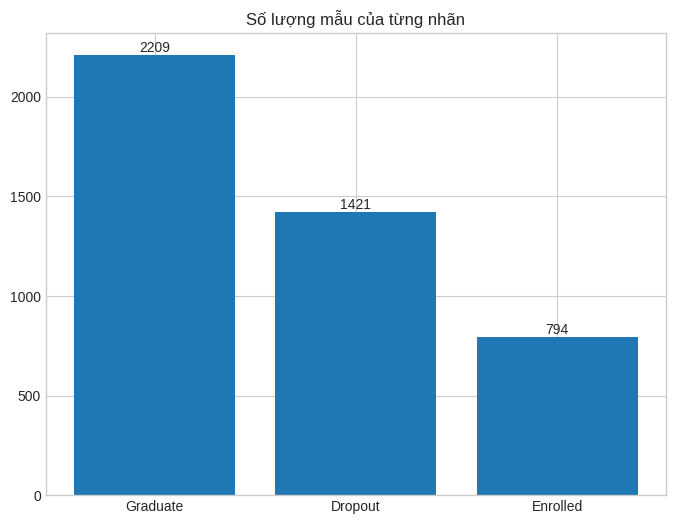

In [114]:
# Đếm số lượng mẫu của mỗi label
targets = df['Target'].value_counts().index
target_counts = df['Target'].value_counts().values

# Vẽ biểu đồ bar
plt.figure(figsize=(8, 6))
plt.bar(targets, target_counts)
for i, value in enumerate(target_counts):
    plt.text(x=i, y=value + 0.5, s=str(value), ha='center', va='bottom')
plt.title('Số lượng mẫu của từng nhãn')
plt.show()

### **2.2 Mối quan hệ giữa Target variable và yếu tố nhân khẩu học**

Dựa vào kết quả phân tích bên dưới ta có thể thấy được mối quan hệ giữa giới tính và tình trạng học tập có độ chênh lệch khá nhiều giữa giá trị `Graduated` và giới tính `Nữ`, điều này cho thấy là phần lớn các học sinh nữ học có tỉ lệ tốt nghiệp cao hơn so với học sinh nam, và tỉ lệ bỏ học của cả 2 giới tính đều cho thấy là cả giới tính `Nam` và `Nữ` đều có tỉ lệ bỏ học ngang nhau. Thêm vào đó, dựa vào phần tích tuổi thì có thể thấy được hầu hết những người có tỉ lệ bỏ học chiếm đa số ở độ tuổi từ $20$ đến $30$ tuổi, điều này cho thấy được đây là người có độ tuổi này họ thường là một người trưởng thành họ bắt đầu tìm kiếm công việc để phục vụ cho cuộc sống hơn là học tập. Cuối cùng là tình trạng hôn nhân, ta có thể thấy được hầu hết những người tốt nghiệp hoặc bỏ học họ đều là những người độc thân và chưa có gia đình. 

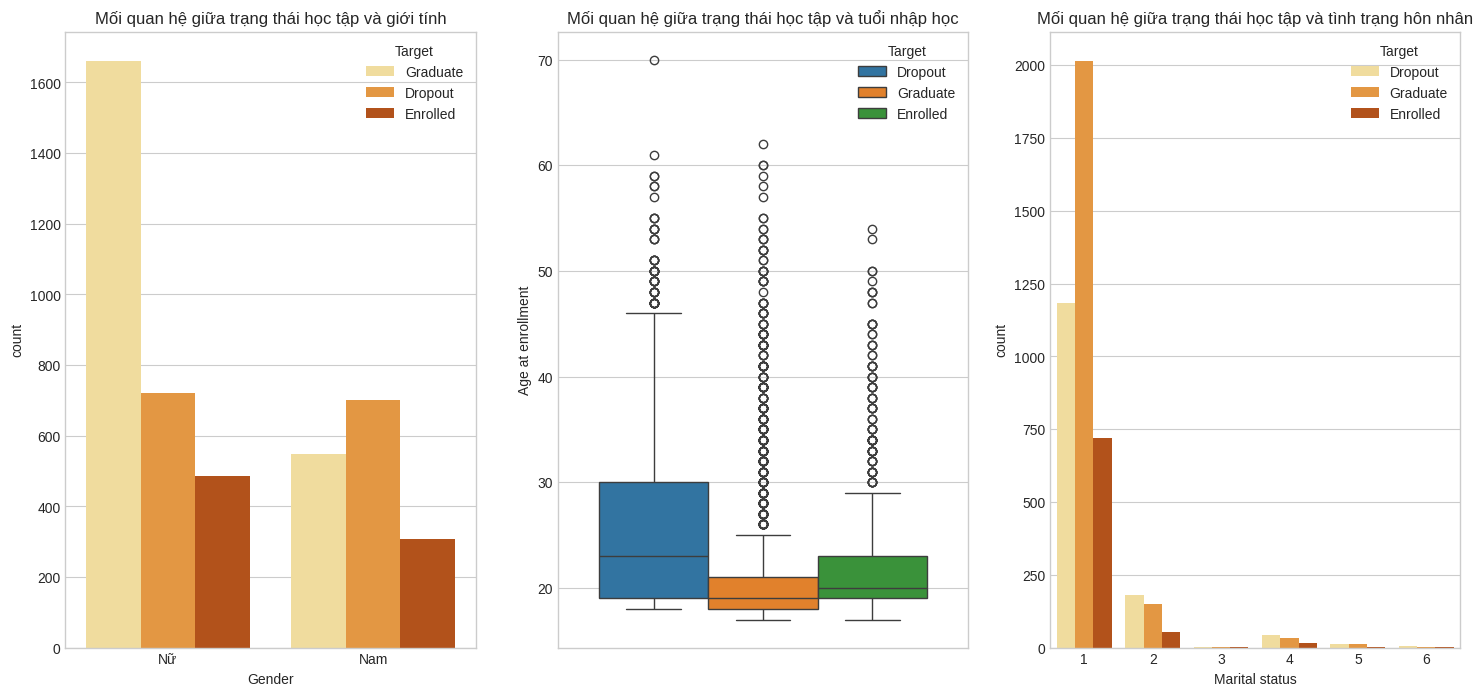

In [115]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 8))

# Giới tính ảnh hưởng thế nào đến trạng thái học tập
sns.countplot(data=df, x='Gender', hue='Target', dodge=True, palette='YlOrBr', ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Nữ", "Nam"])
ax[0].set_title("Mối quan hệ giữa trạng thái học tập và giới tính")

# Tuổi nhập học có ảnh hưởng đến trạng thái học tập hay không
sns.boxplot(data=df, y='Age at enrollment', hue='Target', ax=ax[1])
ax[1].set_title("Mối quan hệ giữa trạng thái học tập và tuổi nhập học")

# Trạng thái hôn nhân ảnh hưởng thế nào đến trạng thái học tập
sns.countplot(data=df, x='Marital status', hue='Target', dodge=True, palette='YlOrBr', ax=ax[2])
ax[2].set_title("Mối quan hệ giữa trạng thái học tập và tình trạng hôn nhân")

plt.show()

### **2.3 Hiệu suất học tập và tình trạng học tập**

Dựa vào kết quả phân tích bên dưới ta có thể thấy được phân bố điểm số của trung bình môn tất cả các môn của sinh viên từ bỏ việc học có xu hướng phân bổ nhiều ở khu vực điểm số thấp, ngoài ra những sinh viên từ bỏ, họ thường có kết quả điểm học kỳ 1 thấp và số tín chỉ đạt được cũng thấp tương tự, từ đó ta có thể phát hiện ra là các sinh viên có điểm số thấp hoặc tín chỉ không đạt yêu cầu thì họ có xu hướng bỏ học nhiều hơn so với sinh viên đang học.

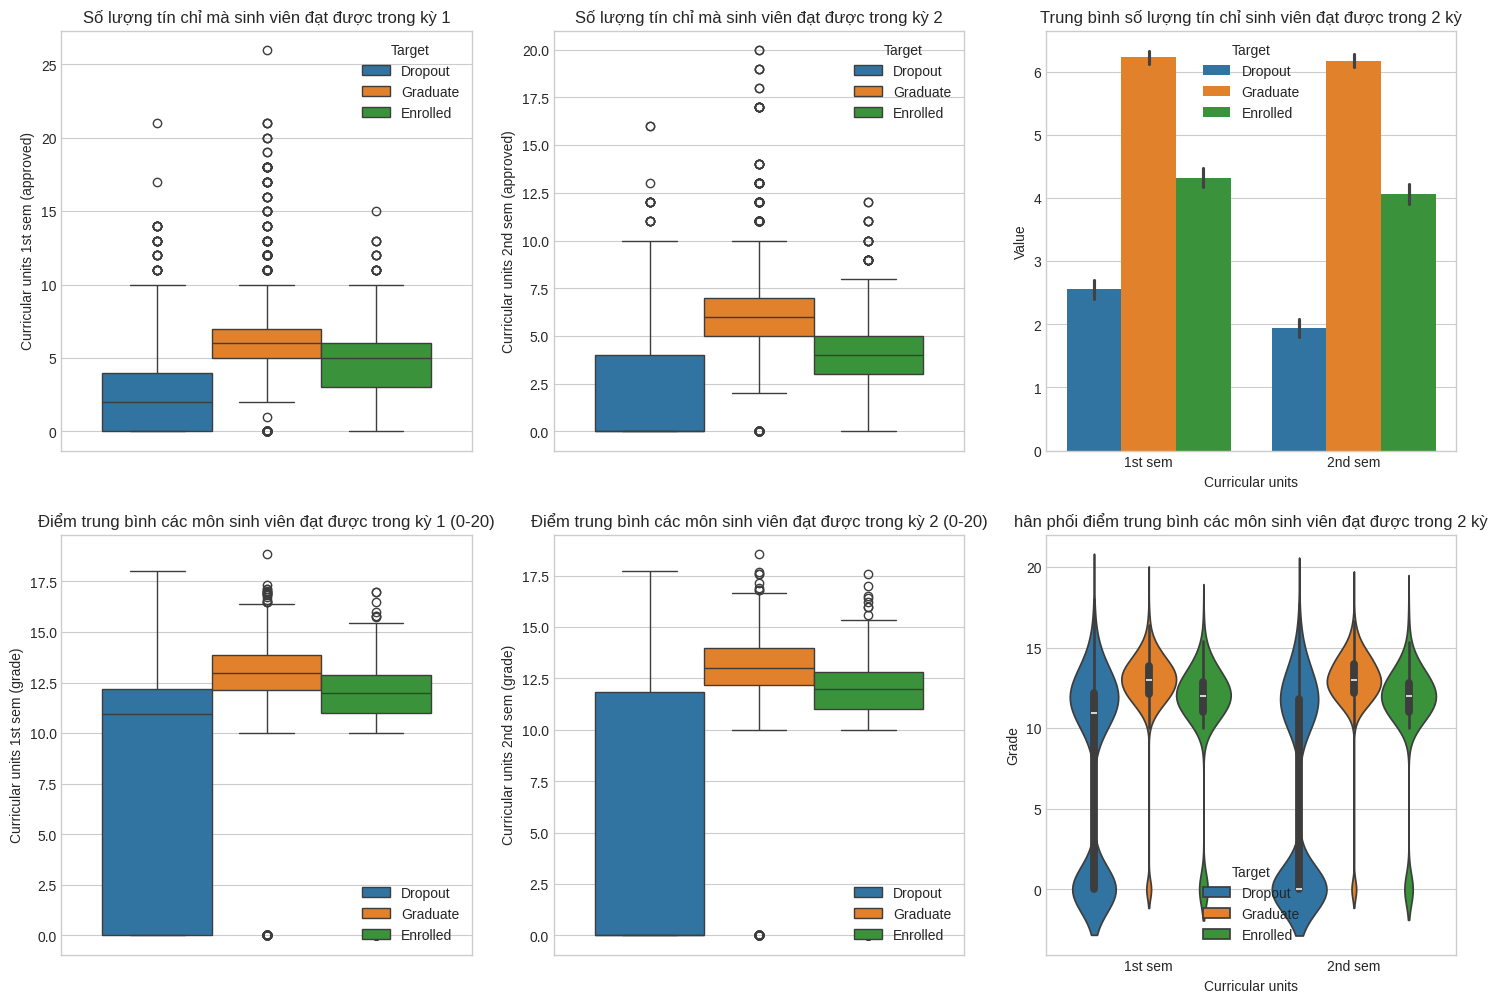

In [116]:
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

# Số lượng tín chỉ sinh viên đạt được trong kỳ 1
sns.boxplot(data=df, y='Curricular units 1st sem (approved)',hue='Target', ax=ax[0, 0])
ax[0, 0].set_title("Số lượng tín chỉ mà sinh viên đạt được trong kỳ 1")

# Số lượng tín chỉ sinh viên đạt được trong kỳ 2
sns.boxplot(data=df, y='Curricular units 2nd sem (approved)', hue='Target', ax=ax[0, 1])
ax[0, 1].set_title("Số lượng tín chỉ mà sinh viên đạt được trong kỳ 2")

# Trung bình số lượng tín chỉ sinh viên đạt được trong 2 kỳ
sns.barplot(
    data=df.melt(
            id_vars=['Target'], 
            value_vars=['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'],
            var_name='Curricular units', 
            value_name='Value'
        ),
    x='Curricular units',
    y='Value', 
    hue='Target', 
    ax=ax[0, 2]
)
ax[0, 2].set_xticks([0, 1])
ax[0, 2].set_xticklabels(['1st sem', '2nd sem'])
ax[0, 2].set_title("Trung bình số lượng tín chỉ sinh viên đạt được trong 2 kỳ")


# Điểm trung bình các môn sinh viên đạt được trong kỳ 1
sns.boxplot(data=df, y='Curricular units 1st sem (grade)',hue='Target', ax=ax[1, 0])
ax[1, 0].set_title("Điểm trung bình các môn sinh viên đạt được trong kỳ 1 (0-20)")
ax[1, 0].legend(loc='lower right')

# Điểm trung bình các môn sinh viên đạt được trong kỳ 2
sns.boxplot(data=df, y='Curricular units 2nd sem (grade)', hue='Target', ax=ax[1, 1])
ax[1, 1].set_title("Điểm trung bình các môn sinh viên đạt được trong kỳ 2 (0-20)")
ax[1, 1].legend(loc='lower right')

# Phân phối điểm trung bình các môn sinh viên đạt được trong 2 kỳ
sns.violinplot(
    data=df.melt(
            id_vars=['Target'], 
            value_vars=['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'],
            var_name='Curricular units', 
            value_name='Grade'
        ),
    x='Curricular units',
    y='Grade', 
    hue='Target', 
    ax=ax[1, 2]
)
ax[1, 2].set_xticks([0, 1])
ax[1, 2].set_xticklabels(['1st sem', '2nd sem'])
ax[1, 2].set_title("hân phối điểm trung bình các môn sinh viên đạt được trong 2 kỳ")

plt.show()

### **2.4 Các yếu tố kinh tế với Target variable**

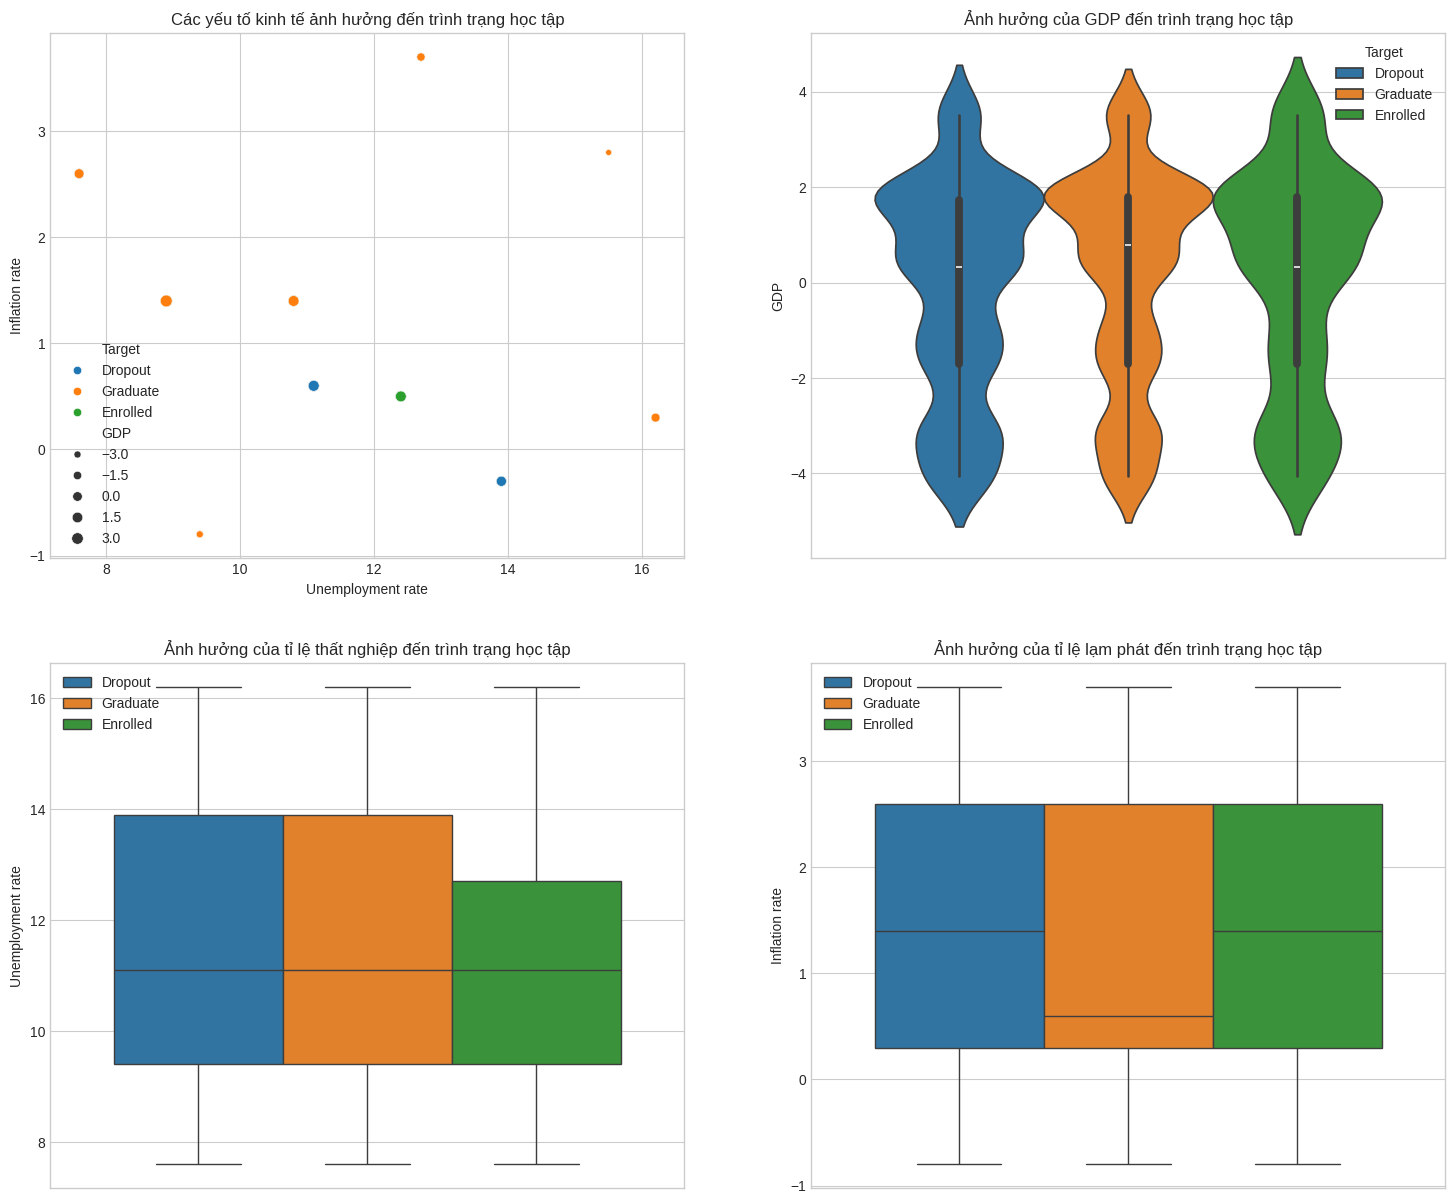

In [117]:
fig, ax = plt.subplots(2, 2, figsize=(18, 15))

# Ảnh hưởng của yếu tố kinh tế đến biến mục tiêu
sns.scatterplot(
    data=df,
    x='Unemployment rate',
    y='Inflation rate',
    hue='Target',
    size='GDP', 
    ax=ax[0, 0]
)
ax[0, 0].set_title('Các yếu tố kinh tế ảnh hưởng đến trình trạng học tập')

# Ảnh hưởng của GDP đến trình trạng học tập
sns.violinplot(
    data=df,
    y='GDP',
    hue='Target',
    ax=ax[0, 1]
)
ax[0, 1].set_title('Ảnh hưởng của GDP đến trình trạng học tập')

# Ảnh hưởng của tỉ lệ thất nghiệp đến trình trạng học tập
sns.boxplot(
    data=df,
    y='Unemployment rate',
    hue='Target',
    ax=ax[1, 0]
)
ax[1, 0].set_title('Ảnh hưởng của tỉ lệ thất nghiệp đến trình trạng học tập')
ax[1, 0].legend(loc='upper left')

# Ảnh hưởng của tỉ lệ lạm phát đến trình trạng học tập
sns.boxplot(
    data=df,
    y='Inflation rate',
    hue='Target',
    ax=ax[1, 1]
)
ax[1, 1].set_title('Ảnh hưởng của tỉ lệ lạm phát đến trình trạng học tập')
ax[1, 1].legend(loc='upper left')

plt.show()

### **2.5 Độ tương quan giữa các thuộc tính**

In [118]:
df_encoded = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)
df_corr = df_encoded.corr()

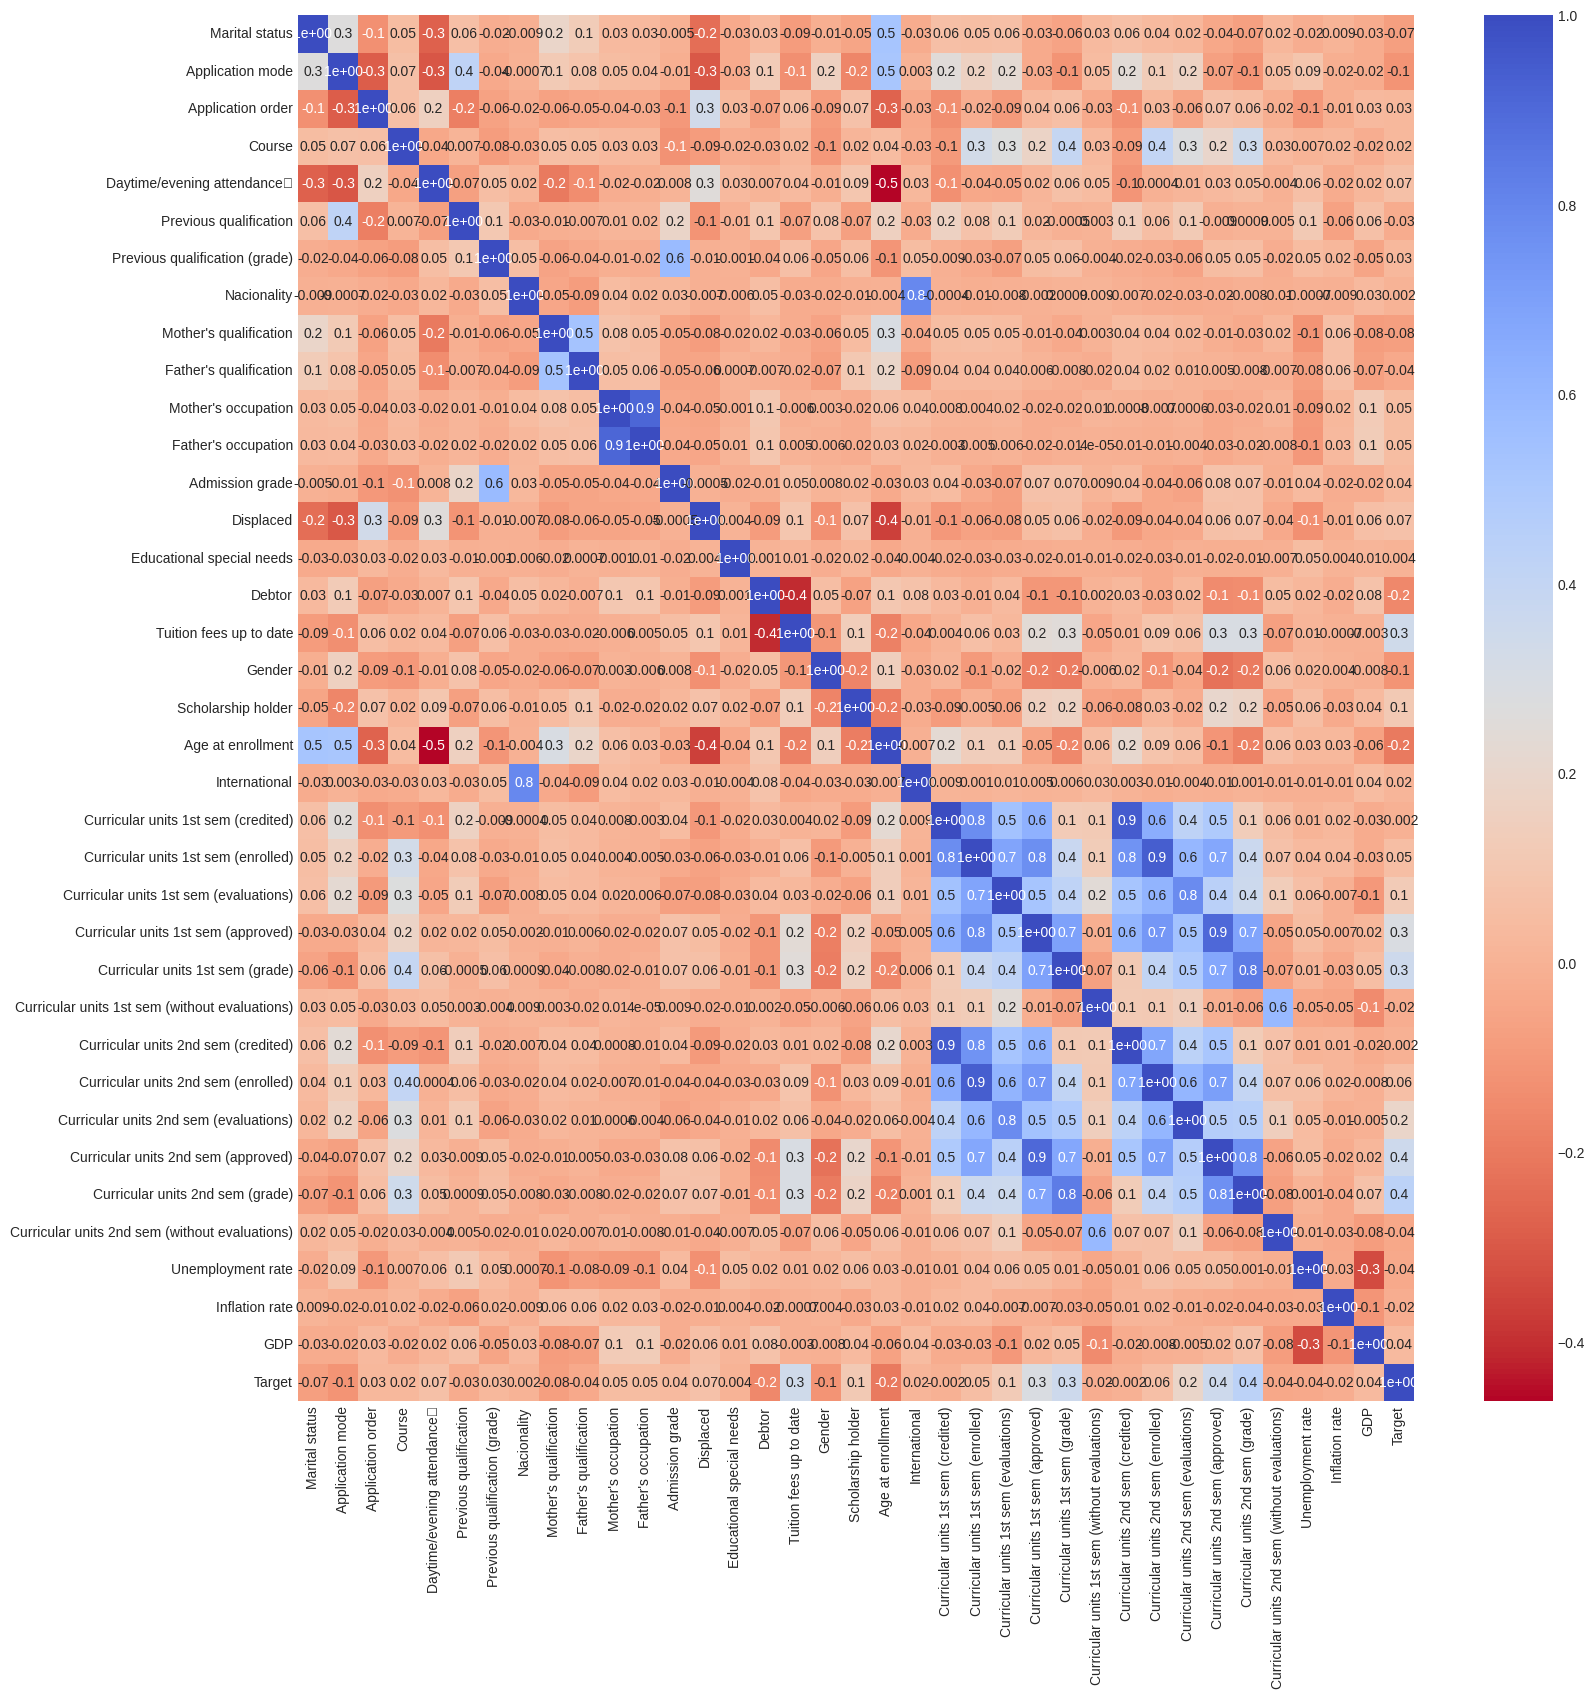

In [119]:
plt.figure(figsize=(18, 18))
sns.heatmap(data=df_corr, cmap='coolwarm_r', fmt='.1', annot=True)
plt.show()

In [120]:
df_corr['Target'].sort_values(ascending=False)[1:]

Curricular units 2nd sem (grade)                  0.429214
Curricular units 2nd sem (approved)               0.351135
Curricular units 1st sem (grade)                  0.349652
Tuition fees up to date                           0.342121
Curricular units 1st sem (approved)               0.290243
Curricular units 2nd sem (evaluations)            0.194412
Curricular units 1st sem (evaluations)            0.125278
Scholarship holder                                0.114517
Displaced                                         0.070649
Daytime/evening attendance\t                      0.066439
Curricular units 2nd sem (enrolled)               0.060670
Curricular units 1st sem (enrolled)               0.052020
Mother's occupation                               0.051664
Father's occupation                               0.051455
Admission grade                                   0.038716
GDP                                               0.037052
Application order                                 0.0273

## **3. Xử lý và tách dữ liệu**

### **3.1 Convert dữ liệu dạng object sang dạng số**

Vì trong dữ liệu chỉ có một cột là kiểu dữ liệu dạng text là cột `Target` nên chúng ta chỉ cần xử lý ở cột này bằng các sử dụng lớp **Label Encoder** của thư viện **Scikit-Learn** để chuyển dữ liệu từ dạng text về dạng số dễ dàng hơn.

In [121]:
# Chuyển từ dạng object sang số của cột target
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Target'])
label_encoder.classes_

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

### **3.2 Tách tập dữ liệu training và test**

Trong dự án lần này tôi sẽ tách tập dữ liệu training và test với tỉ lệ 8:2

In [123]:
# Tách feature và label
X = df.drop('Target', axis=1)
y = df['Target']

# Tách tập training và test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=42)

In [124]:
print(f"Số lượng dòng và cột của đặc trưng tập huấn luyện: {X_train.shape}")
print(f"Số lượng dòng và cột của nhãn tập huấn luyện: {y_train.shape}")
print(f"Số lượng dòng và cột của đặc trưng tập kiểm tra: {X_test.shape}")
print(f"Số lượng dòng và cột của đặc trưng tập kiểm tra: {y_test.shape}")

Số lượng dòng và cột của đặc trưng tập huấn luyện: (3539, 36)
Số lượng dòng và cột của nhãn tập huấn luyện: (3539,)
Số lượng dòng và cột của đặc trưng tập kiểm tra: (885, 36)
Số lượng dòng và cột của đặc trưng tập kiểm tra: (885,)


### **3.3 Chuẩn hóa dữ liệu**

Chuẩn hóa dữ liệu là bước giúp chúng ta tránh được tình trạng chênh lệch đơn vị giữa các đặc trưng và điều này cũng giúp cho mô hình học tốt hơn và tránh được tình trạng overfitting. Trong dự án lần này, vì dữ liệu chúng ta có những cột giá trị thuộc kiểu **Binary** nên chúng tôi sẽ sử dụng kiểu chuẩn hóa **Min Max** để giúp bảo toàn được thông tin cho các cột đặc trưng có giá trị là kiểu binary.

In [125]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [126]:
scaled_X_train[0]

array([0.6       , 0.10714286, 0.11111111, 0.91524402, 1.        ,
       0.04761905, 0.36842105, 0.        , 0.42857143, 0.        ,
       0.0257732 , 0.02564103, 0.36842105, 0.        , 0.        ,
       0.        , 1.        , 0.        , 0.        , 0.33962264,
       0.        , 0.        , 0.19230769, 0.11111111, 0.        ,
       0.        , 0.        , 0.        , 0.2173913 , 0.15151515,
       0.        , 0.        , 0.        , 0.40697674, 0.31111111,
       0.80317041])

## **4. Huấn luyện mô hình**

In [127]:
def evaluation_model(y_true, y_pred, model_name):
    ev_accuracy_score = accuracy_score(y_true, y_pred)
    ev_f1_score = f1_score(y_true, y_pred, average='macro')
    ev_recall_score = recall_score(y_true, y_pred, average='macro')
    ev_precision_score = precision_score(y_true, y_pred, average='macro')

    print(f"Kết quả đánh giá của mô hình {model_name}:")
    print("="*30)
    print(f"Accuracy score: {round(ev_accuracy_score, 2)}")
    print(f"F1 score: {round(ev_f1_score, 2)}")
    print(f"Recall score: {round(ev_recall_score, 2)}")
    print(f"Precision score: {round(ev_precision_score, 2)}")
    print(classification_report(y_true, y_pred))

In [128]:
def compare_models(models_dict, X_test, y_true):
    # Khởi tạo dictionary để lưu các metrics
    results = {
        'Model': [],
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1-Score': [],
    }

    # Tính toán metrics cho từng mô hình
    for name, model in models_dict.items():
        # Dự đoán
        y_pred = model.predict(X_test)

        # Tính các metrics trung bình
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        f1 = f1_score(y_true, y_pred, average='macro')


        # Thêm kết quả vào dictionary
        results['Model'].append(name)
        results['Accuracy'].append(accuracy)
        results['Precision'].append(precision)
        results['Recall'].append(recall)
        results['F1-Score'].append(f1)

    # Chuyển kết quả thành DataFrame
    results_df = pd.DataFrame(results)

    # Định dạng các số thành 4 chữ số thập phân
    float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    results_df[float_cols] = results_df[float_cols].round(4)

    # Vẽ biểu đồ so sánh
    plt.figure(figsize=(15, 6))

    # Vị trí của các cột
    x = np.arange(len(models_dict))
    width = 0.15

    # Vẽ các cột metrics
    plt.bar(x - width*2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
    plt.bar(x - width, results_df['Precision'], width, label='Precision', color='lightgreen')
    plt.bar(x, results_df['Recall'], width, label='Recall', color='salmon')
    plt.bar(x + width, results_df['F1-Score'], width, label='F1-Score', color='purple')

    # Chỉnh sửa đồ thị
    plt.xlabel('Mô hình')
    plt.ylabel('Điểm số')
    plt.title('So sánh hiệu suất các mô hình')
    plt.xticks(x, results_df['Model'])
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Thêm giá trị lên đầu mỗi cột
    for i in range(len(models_dict)):
        plt.text(i - width*2, results_df['Accuracy'][i], f"{results_df['Accuracy'][i]:.3f}",
                ha='center', va='bottom', rotation=0)
        plt.text(i - width, results_df['Precision'][i], f"{results_df['Precision'][i]:.3f}",
                ha='center', va='bottom', rotation=0)
        plt.text(i, results_df['Recall'][i], f"{results_df['Recall'][i]:.3f}",
                ha='center', va='bottom', rotation=0)
        plt.text(i + width, results_df['F1-Score'][i], f"{results_df['F1-Score'][i]:.3f}",
                ha='center', va='bottom', rotation=0)

    plt.tight_layout()
    plt.show()

    return results_df

### **4.1 K-Nearest Neighbors**

In [129]:
# Khởi tạo mô hình
knn_model = KNeighborsClassifier(n_neighbors=25)

# Huấn luyện mô hình
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=25)

In [130]:
# Dự đoán
knn_y_pred = knn_model.predict(scaled_X_test)
knn_y_pred[:10]

array([2, 2, 2, 2, 0, 2, 2, 1, 2, 2])

In [131]:
evaluation_model(y_test, knn_y_pred, "KNN")

Kết quả đánh giá của mô hình KNN:
Accuracy score: 0.68
F1 score: 0.53
Recall score: 0.54
Precision score: 0.62
              precision    recall  f1-score   support

           0       0.87      0.60      0.71       316
           1       0.36      0.07      0.11       151
           2       0.63      0.97      0.76       418

    accuracy                           0.68       885
   macro avg       0.62      0.54      0.53       885
weighted avg       0.67      0.68      0.63       885



### **4.2 Support Vector Machine**

In [132]:
# Khởi tạo mô hình
svm_model = SVC()

# Huấn luyện mô hình
svm_model.fit(scaled_X_train, y_train)

SVC()

In [133]:
# Dự đoán
svm_y_pred = svm_model.predict(scaled_X_test)
svm_y_pred[:10]

array([0, 2, 2, 2, 0, 2, 2, 2, 2, 2])

In [134]:
evaluation_model(y_test, svm_y_pred, "SVM")

Kết quả đánh giá của mô hình SVM:
Accuracy score: 0.75
F1 score: 0.66
Recall score: 0.65
Precision score: 0.71
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       316
           1       0.49      0.29      0.37       151
           2       0.73      0.97      0.83       418

    accuracy                           0.75       885
   macro avg       0.71      0.65      0.66       885
weighted avg       0.75      0.75      0.73       885



### **4.3 So sánh**

In [135]:
models_dict = {
    "KNN": knn_model,
    "SVM": svm_model
}

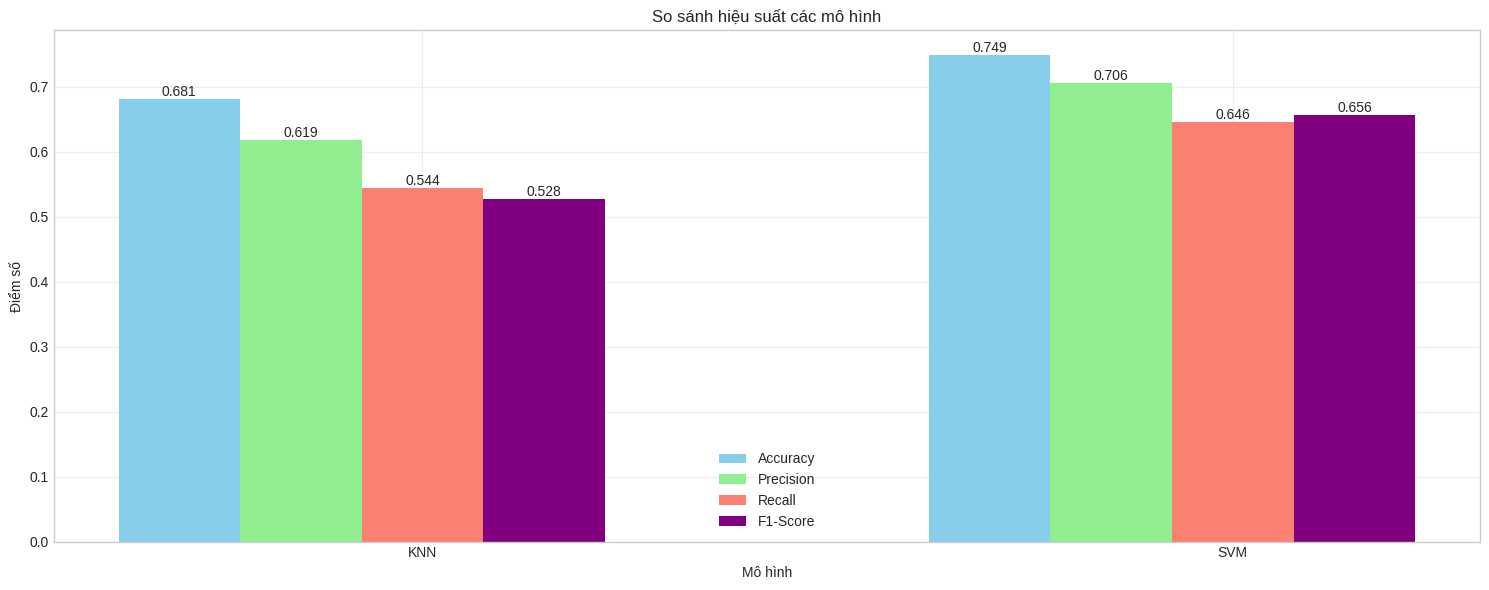

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.6814,0.6188,0.5436,0.5280
1,SVM,0.7492,0.7056,0.6458,0.6562


In [136]:
compare_models(models_dict, scaled_X_test, y_test)

## **5. Tránh Overfitting**

### **5.1 Cross validation và K-Fold**

Cross-validation là một kỹ thuật chia dữ liệu thành nhiều phần (folds), sau đó huấn luyện mô hình trên một phần và kiểm tra trên phần còn lại. Quá trình này được lặp lại nhiều lần để đảm bảo mô hình không bị overfitting vào một phần dữ liệu cụ thể.

<div align="center">
    <img 
        src="https://raw.githubusercontent.com/cleanlab/assets/master/cleanlab/pred_probs_cross_val.png"
        width="500px"
    >
</div>

Cross-validation giúp giảm overfitting vì mô hình được kiểm tra trên nhiều phần khác nhau của dữ liệu, không chỉ một phần duy nhất. Điều này giúp bạn đánh giá được hiệu suất thực sự của mô hình khi sử dụng dữ liệu chưa thấy trước đây.

In [137]:
# Khởi tại K-Fold với 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
kf_svm_model = SVC()

# Chuẩn hoá dữ liệu
scaled_X = MinMaxScaler().fit_transform(X)

# Áp dụng cross-validation với KFold
scores = cross_val_score(kf_svm_model, scaled_X, y, cv=cv)

In [138]:
print("Điểm số trên các fold:", scores)
print("Trung bình điểm số: ", scores.mean())

Điểm số trên các fold: [0.74915254 0.75254237 0.75706215 0.76158192 0.7658371 ]
Trung bình điểm số:  0.7572352174246492


### **5.2 Áp dụng Regularization**

Trong SVM, tham số `C` là tham số điều chỉnh việc điều chỉnh độ chính xác và tính tổng quát của mô hình:
- `C` thấp: Càng giảm `C`, mô hình sẽ có xu hướng hàm lượng regularization cao hơn. Điều này có nghĩa là mô hình có thể chấp nhận nhiều sai số hơn trong quá trình huấn luyện, dẫn đến việc mô hình có thể tổng quát tốt hơn, giảm overfitting.
- `C` cao: Càng tăng `C`, mô hình sẽ có xu hướng tìm cách đặt ra một ranh giới phân loại càng chính xác càng tốt, thậm chí có thể overfit trên dữ liệu huấn luyện, bởi vì mô hình sẽ cố gắng phân loại chính xác mọi điểm dữ liệu, kể cả những điểm nhiễu.

In [139]:
# Khởi tạo mô hình SVM với một giá trị C
rg_svm_model = SVC(C=1.5, kernel='poly', random_state=42)

# Huấn luyện mô hình
rg_svm_model.fit(scaled_X_train, y_train)

SVC(C=1.5, kernel='poly', random_state=42)

In [140]:
# Dự đoán
rgsvm_y_pred = rg_svm_model.predict(scaled_X_test)
rgsvm_y_pred[:10]

array([0, 2, 2, 2, 0, 2, 2, 2, 2, 2])

In [141]:
evaluation_model(y_test, rgsvm_y_pred, "SVM đã thêm Regularization")

Kết quả đánh giá của mô hình SVM đã thêm Regularization:
Accuracy score: 0.77
F1 score: 0.69
Recall score: 0.68
Precision score: 0.72
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       316
           1       0.51      0.38      0.44       151
           2       0.77      0.93      0.84       418

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



In [142]:
models_dict = {
    "SVM": svm_model,
    "SVM đã thêm Regularization": rg_svm_model
}

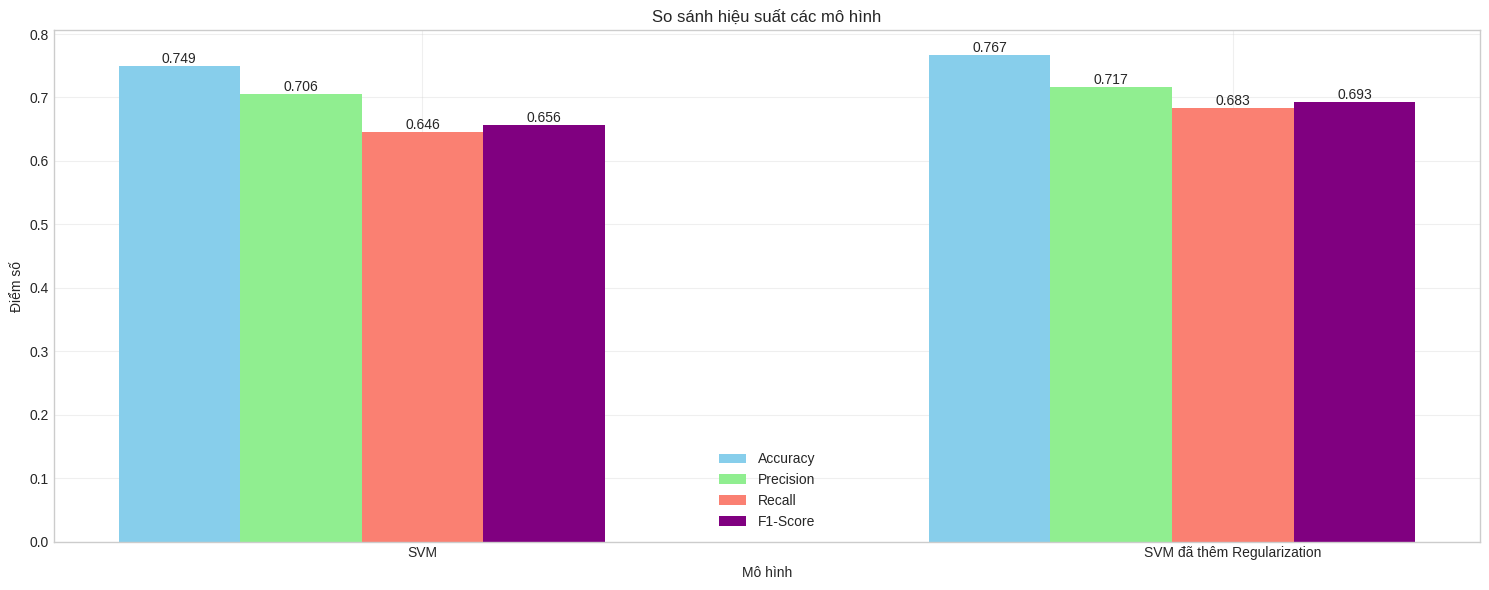

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.7492,0.7056,0.6458,0.6562
1,SVM đã thêm Regularization,0.7672,0.7171,0.6832,0.6929


In [143]:
compare_models(models_dict, scaled_X_test, y_test)

### **5.3 Giảm số lượng feature**

In [178]:
# Chọn 15 đặc trưng tốt nhất
selector = SelectKBest(score_func=f_classif, k=20) 
new_X = selector.fit_transform(X, y)

# Tách dữ liệu train và test
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, y, train_size=0.8, shuffle=True, random_state=42)

# Chuẩn hóa dữ liệu
new_scaler = MinMaxScaler()
new_X_train = new_scaler.fit_transform(new_X_train)
new_X_test = new_scaler.transform(new_X_test)

In [179]:
print(f"Số lượng dòng và cột của đặc trưng tập huấn luyện: {new_X_train.shape}")
print(f"Số lượng dòng và cột của đặc trưng tập kiểm tra: {new_X_test.shape}")

Số lượng dòng và cột của đặc trưng tập huấn luyện: (3539, 20)
Số lượng dòng và cột của đặc trưng tập kiểm tra: (885, 20)


In [180]:
# Khởi tạo mô hình SVM cho dữ liệu đã chọn feature tốt nhất
fs_svm_model = SVC()

# Huấn luyện mô hình trên dữ liệu mới
fs_svm_model.fit(new_X_train, new_y_train)

SVC()

In [181]:
new_y_pred = fs_svm_model.predict(new_X_test)
new_y_pred[:10]

array([0, 2, 2, 2, 0, 1, 2, 2, 2, 2])

In [182]:
evaluation_model(new_y_test, new_y_pred, 'SVM với feature selection')

Kết quả đánh giá của mô hình SVM với feature selection:
Accuracy score: 0.74
F1 score: 0.65
Recall score: 0.64
Precision score: 0.68
              precision    recall  f1-score   support

           0       0.88      0.67      0.76       316
           1       0.44      0.31      0.36       151
           2       0.74      0.94      0.83       418

    accuracy                           0.74       885
   macro avg       0.68      0.64      0.65       885
weighted avg       0.74      0.74      0.73       885



### **5.4 Giảm kích thước hoặc điều chỉnh tham số mô hình**

In [185]:
# Định nghĩa các tham số cần tìm kiếm
param_grid = {
    'n_neighbors': [5, 10, 15, 20, 25, 30],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40, 50]
}

In [186]:
# Tạo đối tượng GridSearchCV
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

In [187]:
# Thực hiện tìm kiếm
grid_search.fit(scaled_X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [10, 20, 30, 40, 50],
                         'n_neighbors': [5, 10, 15, 20, 25, 30],
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [188]:
# In ra tham số tốt nhất
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 5, 'weights': 'distance'}
Best cross-validation score: 0.5863787571408409


In [190]:
# Tạo mô hình với tham số tốt nhất
best_knn_model = KNeighborsClassifier(**grid_search.best_params_)
best_knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(leaf_size=10, weights='distance')

In [192]:
best_knn_y_pred = best_knn_model.predict(scaled_X_test)
best_knn_y_pred[:10]

array([2, 2, 2, 1, 0, 2, 2, 0, 2, 2])

In [193]:
evaluation_model(y_test, best_knn_y_pred, 'KNN với tham số tốt nhất')

Kết quả đánh giá của mô hình KNN với tham số tốt nhất:
Accuracy score: 0.68
F1 score: 0.59
Recall score: 0.59
Precision score: 0.62
              precision    recall  f1-score   support

           0       0.82      0.63      0.72       316
           1       0.35      0.26      0.30       151
           2       0.68      0.86      0.76       418

    accuracy                           0.68       885
   macro avg       0.62      0.59      0.59       885
weighted avg       0.68      0.68      0.67       885



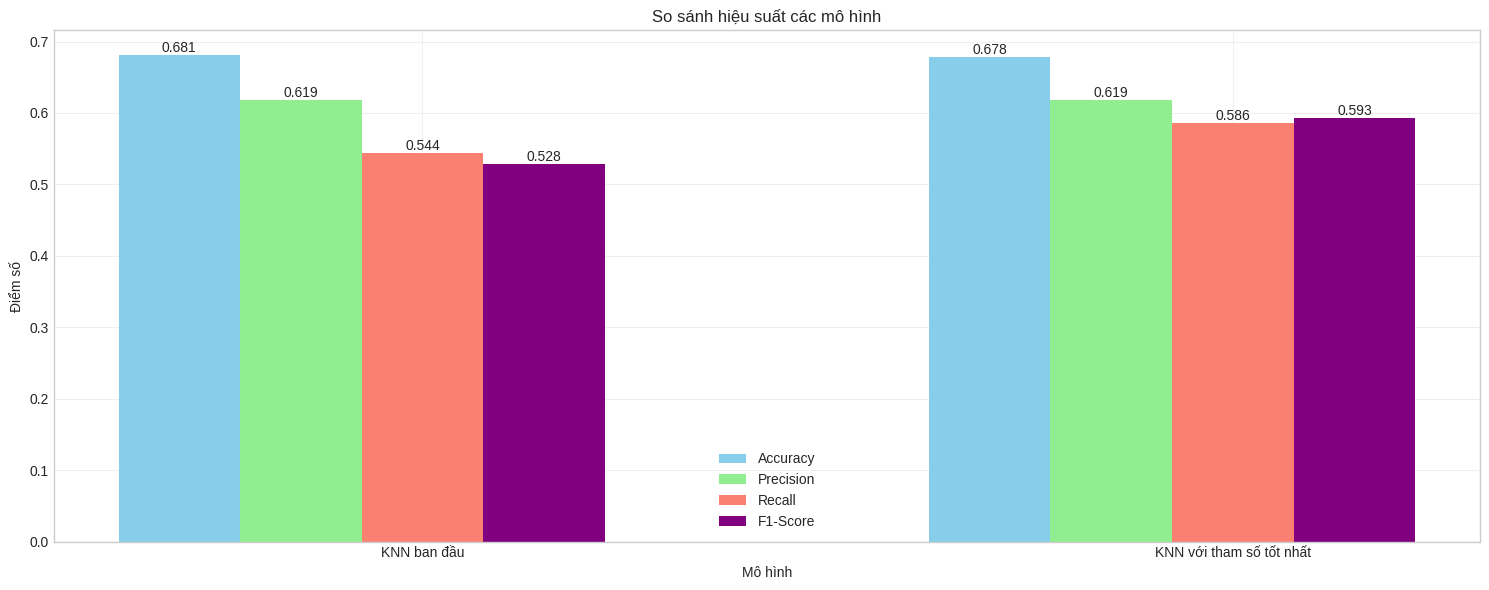

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN ban đầu,0.6814,0.6188,0.5436,0.5280
1,KNN với tham số tốt nhất,0.6780,0.6186,0.5864,0.5928


In [194]:
models_dict = {
    "KNN ban đầu": knn_model,
    "KNN với tham số tốt nhất": best_knn_model
}

compare_models(models_dict, scaled_X_test, y_test)